# Workflow: Predicting Player Weight with Linear Regression

This workflow demonstrates the practical application of the Ordinary Least Squares (OLS) Linear Regression model. The goal is to model the relationship between physical attributes—specifically, predicting a Wide Receiver's weight based on their height—using real-world data from the Madden dataset.

## 1. Data Acquisition & Filtering

The process begins by loading the `madden.csv` dataset. To ensure a strong correlation and cleaner data distribution, we filter the dataset to isolate a single position group: Wide Receivers (WR). This removes the noise introduced by positions with vastly different body types (e.g., Offensive Linemen vs. Kickers).

## 2. Data Preparation

We extract the relevant feature (height) and target (weight) columns. Using our custom `train_test_split_arrays` utility, the data is divided into two distinct sets:

- **Training Set (80%)**: Used to calculate the optimal regression coefficients.  
- **Testing Set (20%)**: Held back to objectively evaluate the model's generalization performance.

## 3. Model Fitting

We initialize the `LinearRegression` class with `fit_intercept=True` and train it on the Training Set. The model solves the Normal Equation to find the line of best fit that minimizes the sum of squared residuals between the actual and predicted weights.

## 4. Visualization & Evaluation

To validate the model, we perform a two-step analysis:

- **Training Visualization:** We plot the regression line against the training data to visually confirm that the model has learned the underlying linear trend.  
- **Testing Evaluation:** We predict weights for the unseen Testing Set and calculate two key metrics:  
  - **Mean Squared Error (MSE):** To quantify the average squared magnitude of the errors.  
  - **Explained Variance ($R^2$):** To understand what proportion of the weight variance is captured by height alone.

Finally, we visualize the model against the testing data to ensure the relationship holds true for new, unseen samples.

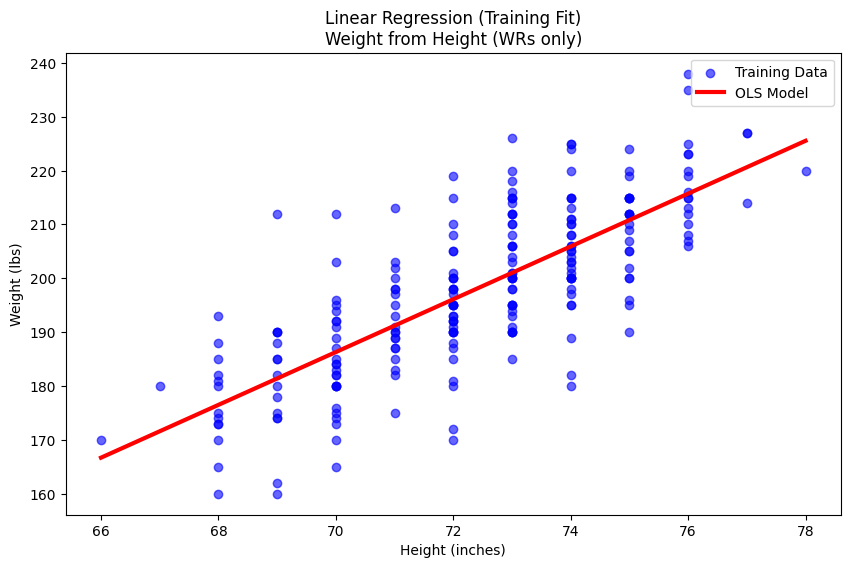

Calculated MSE on Test Set: 79.93
Total Variance of Target:   222.20
Explained Variance (R^2):   0.6403


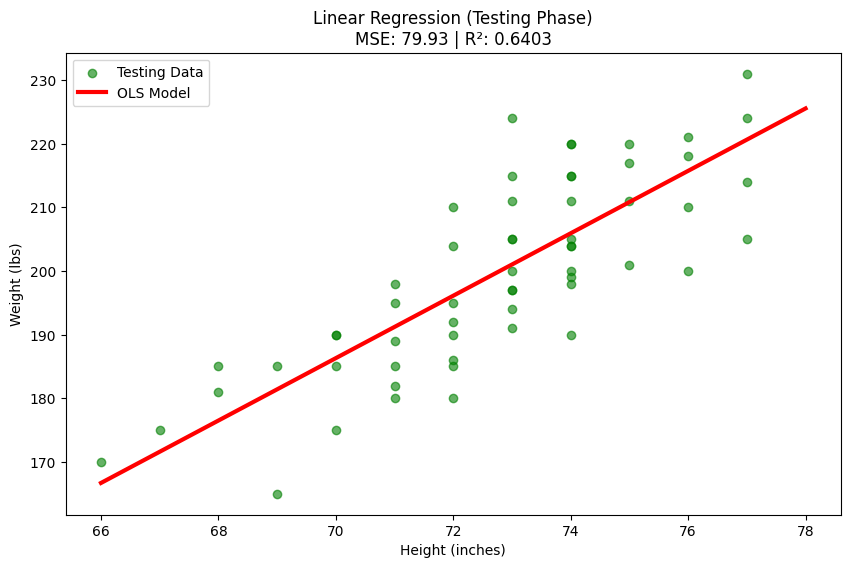

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the custom implementations
from ml import LinearRegression
from ml import train_test_split_arrays 

# 1. Load Data & Filter
# Load the dataset and extract only Wide Receivers
df = pd.read_csv('madden.csv')
wr_data = df[df['Position'] == 'WR'].copy()

# 2. Prepare Features and Targets
# Extract height as the feature (X) and weight as the target (y)
# Reshape X to be 2D as required by the custom model
X = wr_data[['Height']].values 
y = wr_data['Weight'].values

# 3. Train Test Split
# Split the dataset into training (80%) and testing (20%) sets using the custom function
# Note: train_test_split_arrays returns (X_train, y_train, X_test, y_test)
X_train, y_train, X_test, y_test = train_test_split_arrays(
    data=X, 
    labels=y, 
    train_ratio=0.8, 
    seed=42
)

# 4. Fit the Model
# Initialize the custom Linear Regression class and fit it to the training data
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

# Generate points for the regression line to use in plots
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_range)

# 5. Visualization: Training Data
# Plot the model against the training data to visualize the fit
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Training Data')
plt.plot(x_range, y_line, color='red', linewidth=3, label='OLS Model')
plt.title("Linear Regression (Training Fit)\nWeight from Height (WRs only)")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (lbs)")
plt.legend()
plt.show()

# 6. Evaluation
# A. Calculate Mean Squared Error (Unexplained Variation)
y_pred_test = model.predict(X_test)
test_mse = model.mean_squared_error(X_test, y_test)

# B. Calculate Total Variance (Total Variation)
# This is the variance of the actual data * number of samples (Sum of Squares Total)
# Or simply: sum((y - mean(y))^2)
total_variance = np.var(y_test) 

# C. Calculate Explained Variance Ratio (R^2)
# How much of the variance in Weight is explained by Height?
# Note: We use 1 - (MSE / Variance)
r2_score = 1 - (test_mse / total_variance)

print(f"Calculated MSE on Test Set: {test_mse:.2f}")
print(f"Total Variance of Target:   {total_variance:.2f}")
print(f"Explained Variance (R^2):   {r2_score:.4f}")

# 7. Visualization: Testing Data
# Update title to include R^2
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='green', alpha=0.6, label='Testing Data')
plt.plot(x_range, y_line, color='red', linewidth=3, label='OLS Model')
plt.title(f"Linear Regression (Testing Phase)\nMSE: {test_mse:.2f} | R²: {r2_score:.4f}")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (lbs)")
plt.legend()
plt.show()

## Conclusion & Analysis

The visualization demonstrates that the linear model successfully captures the underlying trend in the data, fitting both the training and testing distributions well. The positive linear relationship between height and weight is clearly visible in the regression plots.

**Quantitative Results:**

- **Mean Squared Error (MSE):** 79.93  
- **Total Variance:** 222.20  
- **Explained Variance ($R^2$):** 0.6403  

**Verdict:**  
With an $R^2$ score of 0.6403, the model explains approximately 64% of the variability in a Wide Receiver's weight based solely on their height. This confirms that while height is a strong predictor, other factors (such as build and muscle mass) contribute significantly to the remaining variance.